# Naive Bayes - Gaussiano y Multinomial
#Aprendizaje Automático
Universidad de Guayaquil — Carrera de Ciencia de Datos e Inteligencia Artificial  
**Asignatura:** Aprendizaje Automático  
**Autora:** Kathia Dennisse Parrales Moreno  
**Fecha:** 15 de junio del 2026

## Importación de librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report, precision_score, recall_score,f1_score,roc_auc_score, roc_curve)

---
## Parte 1: Naive Bayes Gaussiano

 Se utiliza cuando las características del dataset son continuas y se asume que siguen una distribución normal gaussiana. En el dataset breast_cancer, contiene medidas de tumores para clasificar si son malignos o benignos.

### 1.1 Carga del dataset y división

In [3]:
datos = load_breast_cancer()

X = datos.data
y = datos.target

print("Forma del dataset:", X.shape)
print("Clases:", datos.target_names)

Forma del dataset: (569, 30)
Clases: ['malignant' 'benign']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

### 1.2 Entrenamiento del modelo

In [5]:
modelo = GaussianNB()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
y_probs = modelo.predict_proba(X_test)[:, 1]

print("Accuracy del Gaussian NB:", accuracy_score(y_test, y_pred))

Accuracy del Gaussian NB: 0.9210526315789473


### 1.3 Matriz de Confusión

Permite ver cuántas predicciones fueron correctas e incorrectas, desglosadas por clase. Las filas representan los valores reales y las columnas los valores predichos.

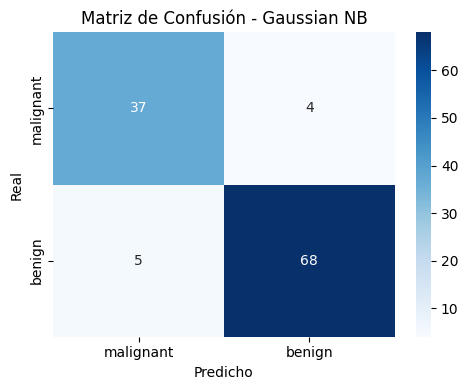

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=datos.target_names,
            yticklabels=datos.target_names)
plt.title('Matriz de Confusión - Gaussian NB')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

### 1.4 Métricas de Evaluación

Calculamos las principales métricas para evaluar el desempeño del clasificador:

- **Accuracy**: proporción de predicciones correctas sobre el total.
- **Precisión**: de todos los que el modelo predijo como positivos, ¿cuántos realmente lo son? Es importante cuando los falsos positivos son costosos.
- **Recall**: de todos los casos positivos reales, ¿cuántos detectó el modelo? En aplicaciones médicas donde no detectar un caso positivo puede ser grave.
- **F1-Score**: media armónica entre precisión y recall. Útil cuando hay desbalance de clases.
- **AUC-ROC**: mide la capacidad del modelo para distinguir entre clases. Un valor de 1.0 es perfecto y 0.5 equivale a clasificación aleatoria.

In [7]:
print("=== MÉTRICAS DE EVALUACIÓN - Gaussian NB ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisión : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_probs):.4f}")
print()
print("=== REPORTE COMPLETO ===")
print(classification_report(y_test, y_pred, target_names=datos.target_names))

=== MÉTRICAS DE EVALUACIÓN - Gaussian NB ===
Accuracy  : 0.9211
Precisión : 0.9444
Recall    : 0.9315
F1-Score  : 0.9379
AUC-ROC   : 0.9840

=== REPORTE COMPLETO ===
              precision    recall  f1-score   support

   malignant       0.88      0.90      0.89        41
      benign       0.94      0.93      0.94        73

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.91       114
weighted avg       0.92      0.92      0.92       114



### 1.5 Curva ROC

La curva ROC representa gráficamente la relación entre la tasa de verdaderos positivos (Recall) y la tasa de falsos positivos a distintos umbrales de clasificación. Cuanto más se acerque la curva a la esquina superior izquierda, mejor es el modelo.

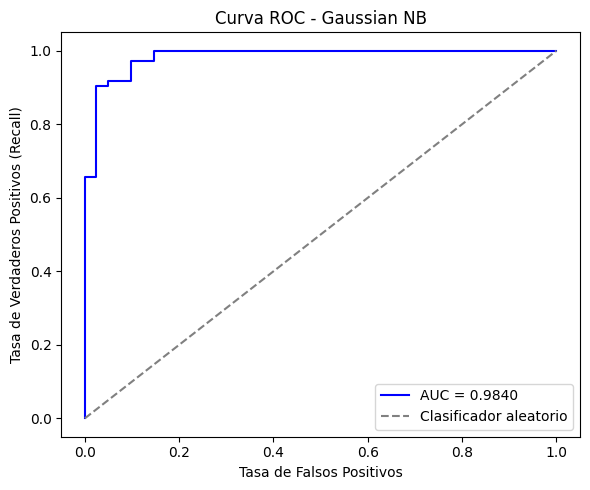

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC - Gaussian NB')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 1.6 Interpretación de Resultados - Gaussian NB

El modelo clasifica correctamente la mayoría de los tumores entre malignos y benignos. El Recall es la métrica más relevante aquí, ya que en un contexto médico es más crítico no dejar pasar un tumor maligno que tener algún falso positivo. El AUC-ROC confirma que el modelo distingue bien entre ambas clases.


## Parte 2: Naive Bayes Multinomial

El Naive Bayes Multinomial está diseñado para datos de texto o conteos de frecuencias. Es muy utilizado en clasificación de texto porque trabaja bien con la representación Bag of Words=conteo de palabras. En este caso clasificamos artículos de noticias en dos categorías: ciencia espacial y béisbol.

### 2.1 Carga del dataset de texto

In [9]:
categorias = [
    'sci.space',
    'rec.sport.baseball'
]

datos_text = fetch_20newsgroups(subset='train', categories=categorias)

print("Categorías:", datos_text.target_names)
print("Total de documentos de entrenamiento:", len(datos_text.data))

Categorías: ['rec.sport.baseball', 'sci.space']
Total de documentos de entrenamiento: 1190


### 2.2 Vectorización y entrenamiento

Convertimos el texto a una representación numérica usando CountVectorizer, que cuenta la frecuencia de cada palabra en cada documento.

In [10]:
vectorizador = CountVectorizer()

Xm = vectorizador.fit_transform(datos_text.data)
ym = datos_text.target

X_trainM, X_testM, y_trainM, y_testM = train_test_split(Xm, ym, test_size=0.3, random_state=24)

modeloM = MultinomialNB()
modeloM.fit(X_trainM, y_trainM)

y_predM = modeloM.predict(X_testM)  # Corregido: usar modeloM (no modelo)
y_probsM = modeloM.predict_proba(X_testM)[:, 1]

print("Accuracy del Multinomial NB:", accuracy_score(y_testM, y_predM))

Accuracy del Multinomial NB: 0.9971988795518207


### 2.3 Matriz de Confusión - Multinomial NB

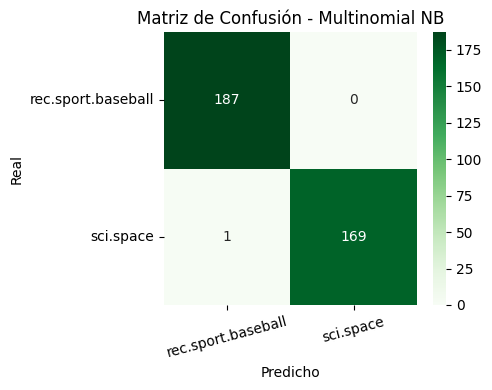

In [11]:
cmM = confusion_matrix(y_testM, y_predM)

plt.figure(figsize=(5, 4))
sns.heatmap(cmM, annot=True, fmt='d', cmap='Greens',
            xticklabels=datos_text.target_names,
            yticklabels=datos_text.target_names)
plt.title('Matriz de Confusión - Multinomial NB')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.4 Métricas de Evaluación - Multinomial NB

In [12]:
print("=== MÉTRICAS DE EVALUACIÓN - Multinomial NB ===")
print(f"Accuracy  : {accuracy_score(y_testM, y_predM):.4f}")
print(f"Precisión : {precision_score(y_testM, y_predM):.4f}")
print(f"Recall    : {recall_score(y_testM, y_predM):.4f}")
print(f"F1-Score  : {f1_score(y_testM, y_predM):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_testM, y_probsM):.4f}")
print()
print("=== REPORTE COMPLETO ===")
print(classification_report(y_testM, y_predM, target_names=datos_text.target_names))

=== MÉTRICAS DE EVALUACIÓN - Multinomial NB ===
Accuracy  : 0.9972
Precisión : 1.0000
Recall    : 0.9941
F1-Score  : 0.9971
AUC-ROC   : 0.9999

=== REPORTE COMPLETO ===
                    precision    recall  f1-score   support

rec.sport.baseball       0.99      1.00      1.00       187
         sci.space       1.00      0.99      1.00       170

          accuracy                           1.00       357
         macro avg       1.00      1.00      1.00       357
      weighted avg       1.00      1.00      1.00       357



### 2.5 Curva ROC - Multinomial NB

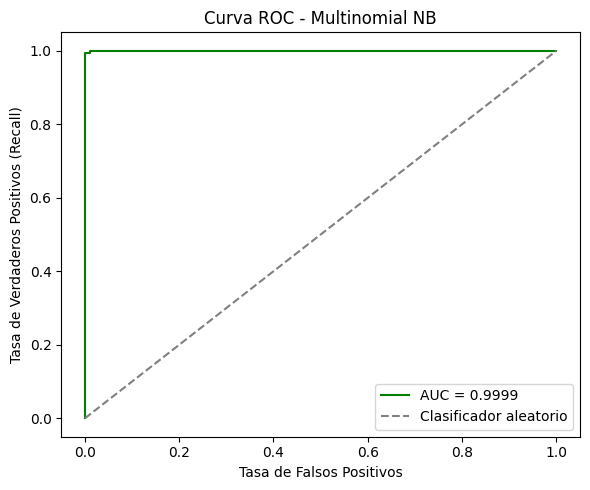

In [13]:
fprM, tprM, _ = roc_curve(y_testM, y_probsM)
aucM = roc_auc_score(y_testM, y_probsM)

plt.figure(figsize=(6, 5))
plt.plot(fprM, tprM, color='green', label=f'AUC = {aucM:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC - Multinomial NB')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 2.6 Interpretación de Resultados - Multinomial NB

El modelo separa sin dificultad los artículos de ciencia espacial y béisbol, lo cual era esperable dado que el vocabulario de cada tema es muy distinto. La precisión y el recall altos indican que casi no hay confusión entre categorías, y el AUC-ROC refleja una separación prácticamente limpia entre las dos clases.

## Comparación Final: Gaussian NB vs Multinomial NB

Ambas variantes de Naive Bayes demostraron ser efectivas en su contexto. El modelo Gaussiano se adapta bien a datos numéricos continuos como los del dataset de cáncer de mama, mientras que el Multinomial es ideal para texto al trabajar con frecuencias de palabras. La elección del modelo no depende de cuál sea "mejor", sino de la naturaleza del problema.